In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [6]:
import os
os.chdir(r"C:\Users\Alraian Abdelrahim\Stats models DS\Final Project")

In [9]:
# read the data

df = pd.read_csv("cleanedWichita.csv")
df = df.drop(columns = ["Unnamed: 0"])
df.head()

,subject_race,subject_sex,year,hour,day_of_week,month,vehicle_tier,violation_severity,disposition_severity,city_location,age_category
0,unknown,Unknown,2018,18,0,1,ECONOMY,1.0,1.0,central,16-24
1,unknown,Unknown,2018,20,0,1,MID,1.0,1.0,central,25-34
2,unknown,Unknown,2018,21,0,1,ECONOMY,3.0,1.0,central,25-34
3,unknown,Unknown,2018,2,0,1,LUXURY,3.0,0.0,unknown,16-24
4,unknown,Unknown,2018,3,0,1,LUXURY,3.0,1.0,unknown,16-24


## Transformations and their reasonings

In [127]:
# mean dispositions for each year

mean2018 = df[df['year'] == 2018]
mean2018sev = mean2018['disposition_severity'].mean()

mean2019 = df[df['year'] == 2019]
mean2019sev = mean2019['disposition_severity'].mean()

mean2020 = df[df['year'] == 2020]
mean2020sev = mean2020['disposition_severity'].mean()

means = [mean2018sev, mean2019sev, mean2020sev]


In [128]:
# hours vs disposition severity 

hours = df['hour'].unique()

hourVals = []
for hour in hours:
    mean = df[df['hour'] == hour]
    hourVals.append(mean['disposition_severity'].mean())


In [129]:
# day of week vs disposition severity 

days = df['day_of_week'].unique()

dowVals = []
for day in days:
    mean = df[df['day_of_week'] == day]
    dowVals.append(mean['disposition_severity'].mean())



In [130]:
# months of the year vs disposition severity 

months = df['month'].unique()

monthsVals = []
for month in months:
    mean = df[df['month'] == month]
    monthsVals.append(mean['disposition_severity'].mean())

In [131]:
# violation severity vs disposition

severity = df['violation_severity'].unique()

sevVals = []
for sev in severity:
    mean = df[df['violation_severity'] == sev]
    sevVals.append(mean['disposition_severity'].mean())

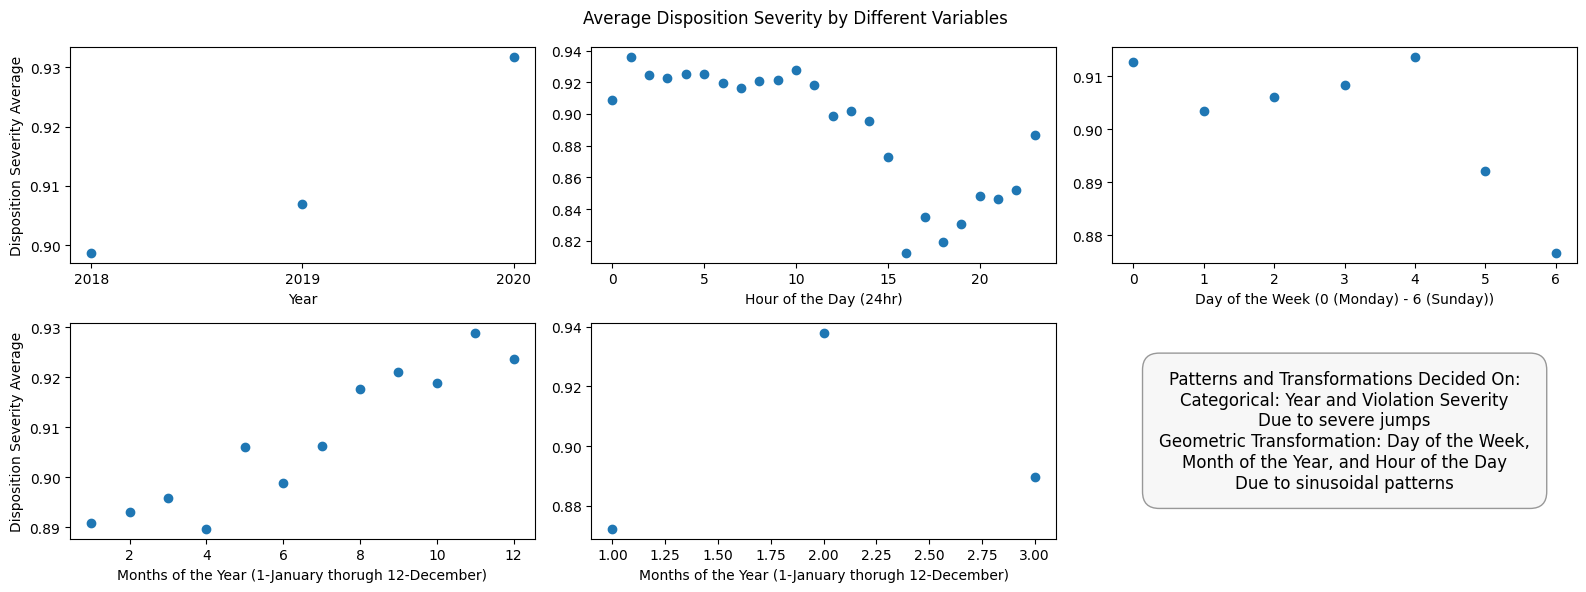

In [132]:
# plot all patterns and note them and transformations decided on

fig, axes = plt.subplots(2, 3, figsize=(16, 6), tight_layout = True)
fig.suptitle("Average Disposition Severity by Different Variables")

# year vs disposition severity 
axes[0,0].scatter(years, means)
axes[0,0].set_ylabel('Disposition Severity Average')
axes[0,0].set_xlabel('Year')

# hours vs disposition severity 
axes[0,1].scatter(hours, hourVals)   
axes[0,1].set_xlabel('Hour of the Day (24hr)')

# day of week vs disposition severity 
axes[0,2].scatter(days, dowVals)   
axes[0,2].set_xlabel('Day of the Week (0 (Monday) - 6 (Sunday))')

# month of the year vs disposition severity 
axes[1,0].scatter(months, monthsVals)   
axes[1,0].set_xlabel('Months of the Year (1-January thorugh 12-December)')
axes[1,0].set_ylabel('Disposition Severity Average')

# violation severity vs disposition severity 
axes[1,1].scatter(severity, sevVals)   
axes[1,1].set_xlabel('Months of the Year (1-January thorugh 12-December)')

# turn last box into summary of patterns

# isolate
last_axes = axes.flatten()[-1]

# Turn off the plot axes 
last_axes.axis("off")

# text content

text_content = (
    "Patterns and Transformations Decided On:\n"
    "Categorical: Year and Violation Severity\n"
    "Due to severe jumps\n"
    "Geometric Transformation: Day of the Week,\n"
    "Month of the Year, and Hour of the Day\n"
    "Due to sinusoidal patterns"    
)

box_style = dict(boxstyle='round,pad=1', facecolor='#f5f5f5', edgecolor='gray', alpha=0.8)

last_axes.text(
    0.5, 0.5,                # Center the text box in the subplot area -> subplot dimensions (0,0 is bottom-left, 1,1 is top-right)
    text_content, 
    transform=last_axes.transAxes, 
    fontsize=12, 
    verticalalignment='center', 
    horizontalalignment='center', 
    bbox=box_style
)

plt.show()


## Variable changes

In [133]:
# Polynomial terms for violation severity produced unstable estimates due to limited distinct values. 
# Severity will instead be modeled as categorical levels to avoid collinearity

df['violation_severity'] = df['violation_severity'].astype('category')

In [134]:
# coverting year to category
df["year_cat"] = df["year"].astype("category")

In [135]:
# cyclic encoding for hour, day of week and month
# Hour (24 hours in a day)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week (7 days)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Month (12 months)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

## Variable category reordering and separation of categorical and numerical variables

In [144]:

df['subject_sex'].unique()

array(['Unknown', 'female', 'male'], dtype=object)

In [150]:
# reordered categories for sex so baseline is male

df['subject_sex'] = pd.Categorical(df['subject_sex'])
df['subject_sex'] = pd.Categorical(
    df['subject_sex'],
    categories=['male','female','Unknown'],
    ordered=False
)


In [151]:
# reordered categories for race so baseline is white

df['subject_race'] = pd.Categorical(df['subject_race'])
df['subject_race'] = pd.Categorical(
    df['subject_race'],
    categories=['white','black','asian/pacific islander','other','unknown'],
    ordered=False
)

In [152]:
# categorical variables
catVars = df.select_dtypes(include = ['object', 'category']).columns

In [153]:
# dummy the cat
dummies = pd.get_dummies(df[catVars], drop_first=True, dtype = int)
dummies.head()

,subject_race_black,subject_race_asian/pacific islander,subject_race_other,subject_race_unknown,subject_sex_female,subject_sex_Unknown,vehicle_tier_LEGACY,vehicle_tier_LUXURY,vehicle_tier_MID,vehicle_tier_MOTORCYCLE,...,city_location_south,city_location_unknown,city_location_west,age_category_25-34,age_category_35-54,age_category_55-64,age_category_65+,age_category_Unknown,year_cat_2019,year_cat_2020
0,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,1,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,1,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,1,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0


In [159]:
# check VIF for cats after making into dummies, dropped vars with VIF > 10
vif_data = pd.DataFrame()
vif_data["feature"] = dummies.columns

vif_data["VIF"] = [variance_inflation_factor(dummies.values, i) for i in range(len(dummies.columns))]
print(vif_data)

                                feature        VIF
0                    subject_race_black   1.135807
1   subject_race_asian/pacific islander   1.034900
2                    subject_race_other   1.003011
3                  subject_race_unknown  31.833839
4                    subject_sex_female   1.425740
5                   subject_sex_Unknown  38.296460
6                   vehicle_tier_LEGACY   1.014711
7                   vehicle_tier_LUXURY   1.013401
8                      vehicle_tier_MID   1.018402
9               vehicle_tier_MOTORCYCLE   1.002651
10                 vehicle_tier_TRAILER   1.001610
11                 vehicle_tier_UNKNOWN   1.009524
12               violation_severity_2.0   1.488873
13               violation_severity_3.0   1.237227
14                   city_location_east   1.889507
15                  city_location_north   1.143418
16                  city_location_south   1.527562
17                city_location_unknown   1.819908
18                   city_locat

In [160]:
colsKeep = vif_data[vif_data["VIF"] < 10]


# Final Dataset

In [163]:
result = pd.concat([
    dummies,
    workingWith[["disposition_severity", "hour_sin", "hour_cos", 
                 "month_sin", "month_cos", "dow_sin", "dow_cos"]]
], axis=1)

result.dtypes

subject_race_black                       int64
subject_race_asian/pacific islander      int64
subject_race_other                       int64
subject_race_unknown                     int64
subject_sex_female                       int64
subject_sex_Unknown                      int64
vehicle_tier_LEGACY                      int64
vehicle_tier_LUXURY                      int64
vehicle_tier_MID                         int64
vehicle_tier_MOTORCYCLE                  int64
vehicle_tier_TRAILER                     int64
vehicle_tier_UNKNOWN                     int64
violation_severity_2.0                   int64
violation_severity_3.0                   int64
city_location_east                       int64
city_location_north                      int64
city_location_south                      int64
city_location_unknown                    int64
city_location_west                       int64
age_category_25-34                       int64
age_category_35-54                       int64
age_category_